# Entregable 1: Storytelling con Datos
## Satisfaccion Ciudadana en Servicios Publicos (2020-2023)

Se explora el dataset de satisfaccion ciudadana, se identifican patrones
y se generan las visualizaciones que acompanan la narrativa del informe.

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Librerias cargadas correctamente')

/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Librerias cargadas correctamente


## 1. Carga y exploracion inicial

In [2]:
df = pd.read_csv('1 Actividad_satisfaccion_servicios_publicos.csv')
print(f'Registros: {len(df)}')
print(f'Columnas: {list(df.columns)}')
print(f'Ciudades: {list(df["Ciudad"].unique())}')
print(f'Servicios: {list(df["Servicio"].unique())}')
print(f'Periodo: {df["Año"].min()} - {df["Año"].max()}')
df.head(10)

Registros: 1000
Columnas: ['ID', 'Ciudad', 'Servicio', 'Año', 'Nivel_Satisfacción', 'Cantidad_Usuarios', 'Usuarios_Satisfechos']
Ciudades: ['Cali', 'Cartagena', 'Medellín', 'Barranquilla', 'Bogotá']
Servicios: ['Salud', 'Transporte', 'Educación', 'Seguridad', 'Ambiente']
Periodo: 2020 - 2023


,ID,Ciudad,Servicio,Año,Nivel_Satisfacción,Cantidad_Usuarios,Usuarios_Satisfechos
0,1,Cali,Salud,2021,5,30257,30257
1,2,Cartagena,Transporte,2022,5,10278,10278
2,3,Cali,Transporte,2022,1,1373,411
3,4,Medellín,Transporte,2021,3,6872,2061
4,5,Barranquilla,Salud,2022,1,43023,12906
5,6,Cali,Educación,2023,1,33571,10071
6,7,Barranquilla,Salud,2020,4,8149,8149
7,8,Medellín,Transporte,2021,2,26598,7979
8,9,Medellín,Educación,2020,2,28894,8668
9,10,Bogotá,Seguridad,2023,4,35072,35072


In [3]:
df.describe()

,ID,Año,Nivel_Satisfacción,Cantidad_Usuarios,Usuarios_Satisfechos
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2021.527000,2.959000,25342.294000,14482.412000
std,288.819436,1.118267,1.392573,14214.802685,13002.410473
min,1.000000,2020.000000,1.000000,1017.000000,349.000000
25%,250.750000,2021.000000,2.000000,12947.500000,5290.000000
50%,500.500000,2022.000000,3.000000,24931.000000,10129.500000
75%,750.250000,2023.000000,4.000000,37640.000000,17976.250000
max,1000.000000,2023.000000,5.000000,49979.000000,49979.000000


In [4]:
# Verificar si hay valores nulos
print('Valores nulos:')
print(df.isnull().sum())

Valores nulos:
ID                      0
Ciudad                  0
Servicio                0
Año                     0
Nivel_Satisfacción      0
Cantidad_Usuarios       0
Usuarios_Satisfechos    0
dtype: int64


## 2. Analisis por servicio, ciudad y ano

In [5]:
# Satisfaccion promedio por servicio
por_servicio = df.groupby('Servicio')['Nivel_Satisfacción'].mean().sort_values(ascending=False)
print('Satisfaccion promedio por servicio:')
print(por_servicio.round(2))

Satisfaccion promedio por servicio:
Servicio
Salud         3.14
Educación     2.98
Ambiente      2.98
Transporte    2.94
Seguridad     2.75
Name: Nivel_Satisfacción, dtype: float64


In [6]:
# Satisfaccion promedio por ciudad
por_ciudad = df.groupby('Ciudad')['Nivel_Satisfacción'].mean().sort_values(ascending=False)
print('Satisfaccion promedio por ciudad:')
print(por_ciudad.round(2))

Satisfaccion promedio por ciudad:
Ciudad
Cartagena       3.10
Barranquilla    3.01
Medellín        2.94
Bogotá          2.92
Cali            2.82
Name: Nivel_Satisfacción, dtype: float64


In [7]:
# Evolucion anual
por_anio = df.groupby('Año')['Nivel_Satisfacción'].mean()
print('Tendencia anual de satisfaccion:')
print(por_anio.round(2))

Tendencia anual de satisfaccion:
Año
2020    3.03
2021    2.85
2022    2.90
2023    3.05
Name: Nivel_Satisfacción, dtype: float64


In [8]:
# Tabla cruzada servicio x ciudad
cross = df.pivot_table(values='Nivel_Satisfacción', index='Servicio', columns='Ciudad', aggfunc='mean').round(2)
print('Satisfaccion por servicio y ciudad:')
cross

Satisfaccion por servicio y ciudad:


Ciudad,Barranquilla,Bogotá,Cali,Cartagena,Medellín
Servicio,,,,,
Ambiente,2.98,2.68,2.97,3.21,3.03
Educación,2.80,3.22,2.89,3.17,2.95
Salud,3.26,3.00,3.14,3.29,2.97
Seguridad,2.96,2.91,2.06,2.88,2.79
Transporte,3.07,2.84,2.92,2.94,2.96


## 3. Visualizaciones

### Visualizacion 1: Barras agrupadas - Satisfaccion por servicio y ano

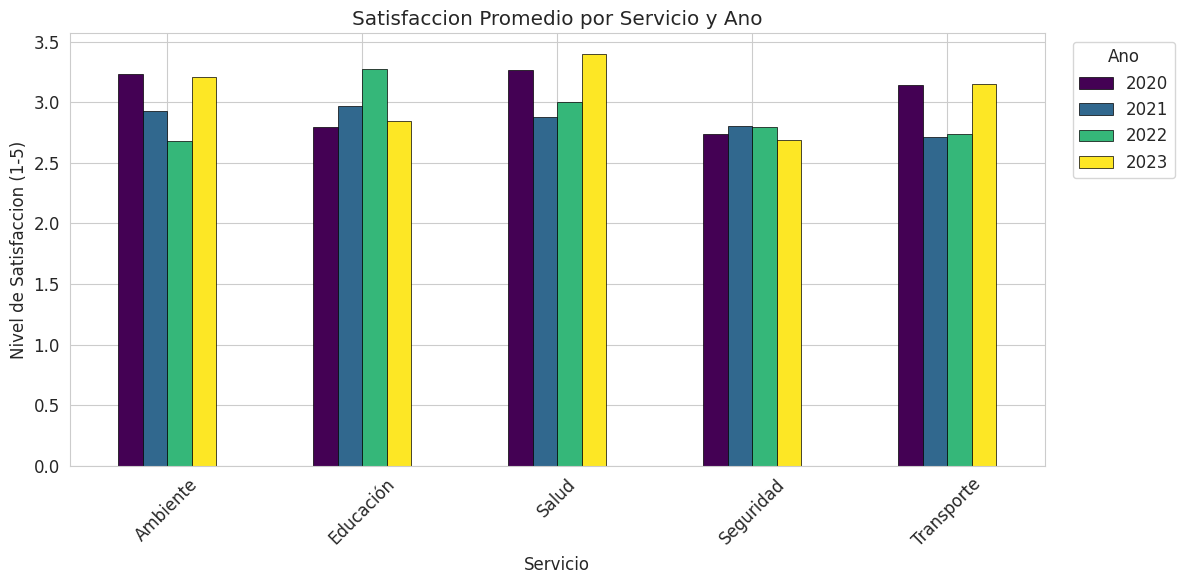

Grafico guardado: vis1_barras_servicio_anio.png


In [9]:
pivot_svc = df.pivot_table(values='Nivel_Satisfacción', index='Servicio', columns='Año', aggfunc='mean')

fig, ax = plt.subplots(figsize=(12, 6))
pivot_svc.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Nivel de Satisfaccion (1-5)')
ax.set_xlabel('Servicio')
ax.set_title('Satisfaccion Promedio por Servicio y Ano')
ax.legend(title='Ano', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('vis1_barras_servicio_anio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: vis1_barras_servicio_anio.png')

### Visualizacion 2: Mapa de calor - Satisfaccion por ciudad y servicio

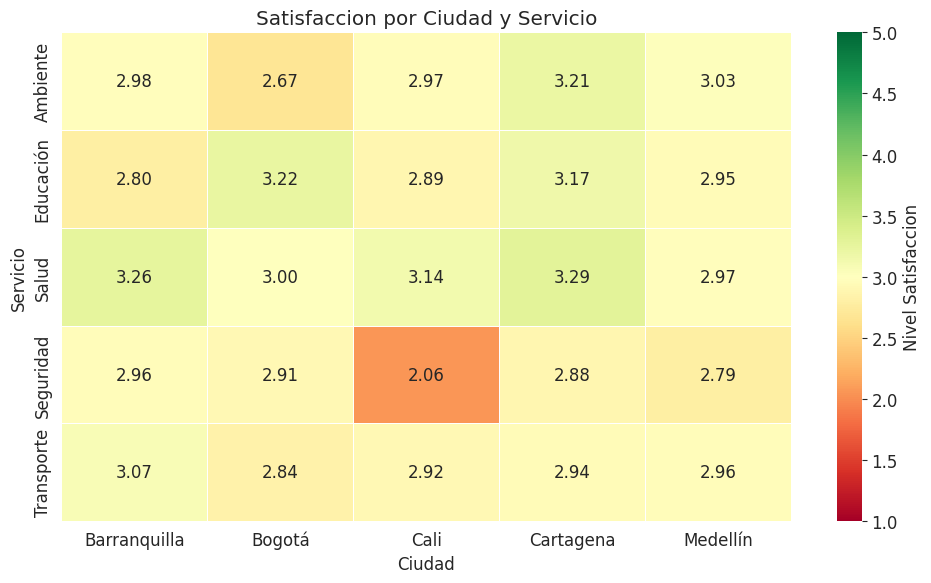

Grafico guardado: vis2_heatmap_ciudad_servicio.png


In [10]:
pivot_heat = df.pivot_table(values='Nivel_Satisfacción', index='Servicio', columns='Ciudad', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_heat, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5,
            vmin=1, vmax=5, cbar_kws={'label': 'Nivel Satisfaccion'}, ax=ax)
ax.set_title('Satisfaccion por Ciudad y Servicio')
plt.tight_layout()
plt.savefig('vis2_heatmap_ciudad_servicio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: vis2_heatmap_ciudad_servicio.png')

### Visualizacion 3: Lineas - Tendencia general por ano

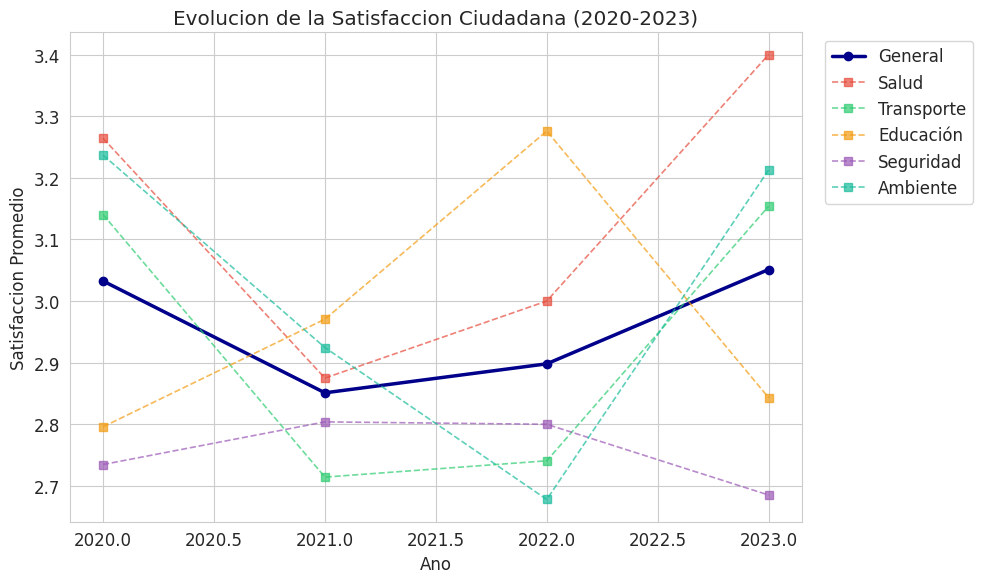

Grafico guardado: vis3_tendencia_anual.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

por_anio.plot(marker='o', linewidth=2.5, color='darkblue', label='General', ax=ax)

colores = ['#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
for i, svc in enumerate(df['Servicio'].unique()):
    data = df[df['Servicio'] == svc].groupby('Año')['Nivel_Satisfacción'].mean()
    data.plot(marker='s', linewidth=1.2, linestyle='--', alpha=0.7,
              label=svc, ax=ax, color=colores[i % len(colores)])

ax.set_ylabel('Satisfaccion Promedio')
ax.set_xlabel('Ano')
ax.set_title('Evolucion de la Satisfaccion Ciudadana (2020-2023)')
ax.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('vis3_tendencia_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado: vis3_tendencia_anual.png')

## 4. Conclusiones

- Se encontraron diferencias importantes tanto entre servicios como entre ciudades.
- La tendencia anual permite ver si las politicas publicas estan teniendo efecto.
- Las tres visualizaciones respaldan la narrativa presentada en el informe.